Loading AI model... (this takes a few seconds)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

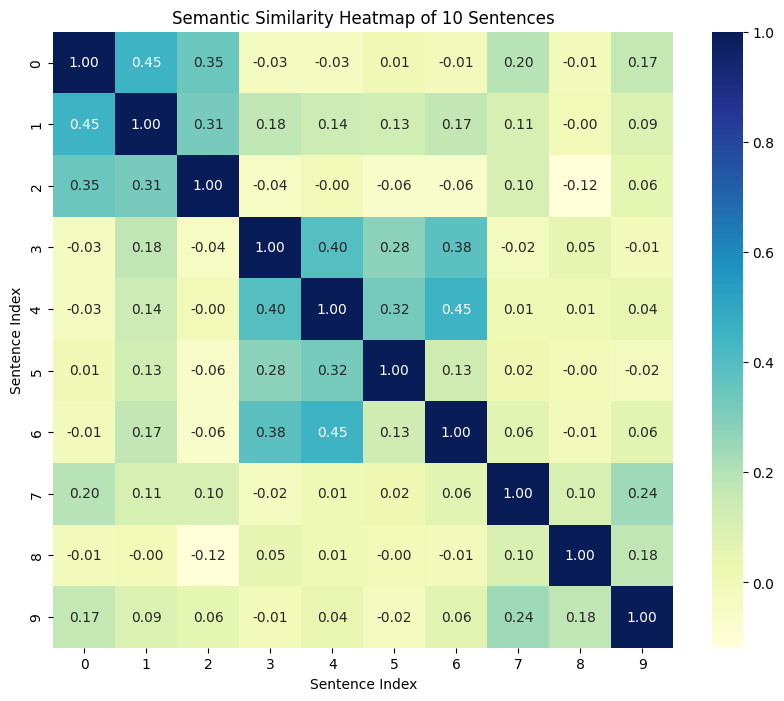


Query: 'The bowler took three wickets in one over'
--------------------------------------------------
Top 2 Most Similar Sentences:
Score: 0.6542 | Sentence: 'The spin bowler delivered a perfect googly to take the wicket.'
Score: 0.5295 | Sentence: 'The batsman hit a massive six over the boundary line.'


In [1]:
# Install the required AI library
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Write 10 sentences across Cricket, Cooking, and Cybersecurity
sentences = [
    # Cricket
    "The batsman hit a massive six over the boundary line.",
    "The spin bowler delivered a perfect googly to take the wicket.",
    "The fielders appealed for an lbw but the umpire said not out.",
    # Cooking
    "Add two cups of flour and a pinch of salt to the mixing bowl.",
    "Sauté the onions and garlic in olive oil until golden brown.",
    "Bake the cake at 350 degrees for about forty-five minutes.",
    "Garnish the pasta with freshly grated parmesan cheese and basil.",
    # Cybersecurity
    "The firewall blocked a massive distributed denial of service attack.",
    "Always use two-factor authentication to secure your online accounts.",
    "The penetration tester found a critical vulnerability in the web app."
]

# 2. Generate embeddings using the specified model
print("Loading AI model... (this takes a few seconds)")
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, show_progress_bar=False)

# 3. Compute and display the 10x10 cosine similarity matrix as a heatmap
cosine_scores = util.cos_sim(embeddings, embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Semantic Similarity Heatmap of 10 Sentences")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()

# 4. Find the top 2 most similar sentences for a new query
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, show_progress_bar=False)

# Calculate similarity between query and all sentences
query_scores = util.cos_sim(query_embedding, embeddings)[0]

# Get the top 2 highest scoring sentence indices
top_results = query_scores.topk(k=2)

print(f"\nQuery: '{query}'")
print("-" * 50)
print("Top 2 Most Similar Sentences:")
for score, idx in zip(top_results[0], top_results[1]):
    print(f"Score: {score:.4f} | Sentence: '{sentences[idx]}'")